# 09 - Decision Curve Analysis

Following **Vickers & Elkin (2006)** and **Vickers et al. (BMJ 2016)**, this notebook computes the **net benefit** of the PCOS screening and enhanced models across a fine grid of threshold probabilities, and compares each model against the two clinical baselines:

- **Treat all** - everyone classified positive (refer everyone).
- **Treat none** - nobody classified positive (do nothing); net benefit is 0.

Net benefit at threshold probability $p_t$ is:

$$
\text{NB}(p_t) = \frac{TP}{N} - \frac{FP}{N} \cdot \frac{p_t}{1 - p_t}
$$

The model adds clinical value over both baselines in the threshold range where its net-benefit curve sits above both reference curves. The deployed action threshold (from notebooks 02 / 03) is marked on each plot.

Outputs:
- `outputs/figures/dca_screening.png`
- `outputs/figures/dca_enhanced.png`
- `outputs/figures/dca_combined.png`
- `outputs/metrics/dca.json`


In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
TEST_SIZE = 0.25
TARGET = "pcos_y_n"

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
METRIC_DIR = OUTPUT_DIR / "metrics"
MODEL_DIR = OUTPUT_DIR / "models"
for folder in (FIGURE_DIR, METRIC_DIR):
    folder.mkdir(parents=True, exist_ok=True)

DATA_PATH = OUTPUT_DIR / "pcos_cleaned.csv"
print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)


Project root: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-aa905b50e9a0daad4
Data path: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-aa905b50e9a0daad4\outputs\pcos_cleaned.csv


## Load Data and Model Artifacts

In [2]:
pcos = pd.read_csv(DATA_PATH)
print("Cleaned PCOS shape:", pcos.shape)
print("Target distribution:")
print(pcos[TARGET].value_counts().sort_index())


Cleaned PCOS shape: (541, 41)
Target distribution:
pcos_y_n
0    364
1    177
Name: count, dtype: int64


In [3]:
MODEL_CONFIGS = {
    "screening": {
        "artifact": MODEL_DIR / "pcos_screening_model.joblib",
        "figure": FIGURE_DIR / "dca_screening.png",
        "title": "Decision Curve - PCOS Screening Model",
        "colour": "#1f77b4",
    },
    "enhanced": {
        "artifact": MODEL_DIR / "pcos_enhanced_model.joblib",
        "figure": FIGURE_DIR / "dca_enhanced.png",
        "title": "Decision Curve - PCOS Enhanced Model",
        "colour": "#6a3d9a",
    },
}

for key, cfg in MODEL_CONFIGS.items():
    cfg["loaded"] = joblib.load(cfg["artifact"])
    print(f"{key}: {cfg['loaded']['model_name']} | threshold={cfg['loaded']['threshold']}"
          f" | n_features={len(cfg['loaded']['features'])}")


screening: random_forest | threshold=0.285 | n_features=13
enhanced: random_forest | threshold=0.38 | n_features=27


## Net-Benefit Helpers

We compute net benefit on the held-out test split for each model. The split mirrors notebooks 02 / 03 exactly (`random_state=42`, `test_size=0.25`, stratified on the target), so we are evaluating the model on data it has not seen during training or threshold tuning.

In [4]:
PT_GRID = np.round(np.arange(0.01, 0.99 + 1e-9, 0.005), 4)

def reproduce_test_split(features):
    """Reproduce the exact 75/25 stratified split used in notebooks 02 and 03."""
    X = pcos[features].copy()
    y = pcos[TARGET].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE,
    )
    return X_test, y_test.to_numpy()

def net_benefit_curve(y_true, y_proba, pt_grid):
    """Net benefit for the model and the 'treat all' baseline across a pt grid.

    NB(pt) = TP/N - FP/N * pt/(1-pt). 'Treat all' classifies every case as positive,
    so TP = positives and FP = negatives at every pt.
    """
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba)
    n = len(y_true)
    prevalence = y_true.mean()
    odds = pt_grid / (1.0 - pt_grid)
    pred = y_proba[None, :] >= pt_grid[:, None]
    tp = (pred & (y_true == 1)[None, :]).sum(axis=1)
    fp = (pred & (y_true == 0)[None, :]).sum(axis=1)
    nb_model = tp / n - fp / n * odds
    nb_treat_all = prevalence - (1.0 - prevalence) * odds
    return nb_model, nb_treat_all

def longest_useful_range(pt_grid, nb_model, nb_treat_all):
    """Longest contiguous pt range where NB_model > max(NB_treat_all, 0)."""
    baseline = np.maximum(nb_treat_all, 0.0)
    is_useful = nb_model > baseline
    best_lo, best_hi, best_len = None, None, 0
    i = 0
    while i < len(is_useful):
        if not is_useful[i]:
            i += 1
            continue
        j = i
        while j < len(is_useful) and is_useful[j]:
            j += 1
        run_len = j - i
        if run_len > best_len:
            best_len = run_len
            best_lo, best_hi = float(pt_grid[i]), float(pt_grid[j - 1])
        i = j
    return [best_lo, best_hi] if best_lo is not None else [None, None]


## Compute Decision Curves

In [5]:
def compute_dca(cfg):
    artifact = cfg["loaded"]
    model = artifact["model"]
    features = artifact["features"]
    threshold = float(artifact["threshold"])
    X_test, y_test = reproduce_test_split(features)
    y_proba = model.predict_proba(X_test)[:, 1]
    nb_model, nb_treat_all = net_benefit_curve(y_test, y_proba, PT_GRID)
    useful = longest_useful_range(PT_GRID, nb_model, nb_treat_all)
    return {
        "threshold": threshold,
        "prevalence": float(np.mean(y_test)),
        "n_test": int(len(y_test)),
        "grid": PT_GRID.tolist(),
        "net_benefit_model": nb_model.tolist(),
        "net_benefit_treat_all": nb_treat_all.tolist(),
        "useful_range": useful,
    }

dca_results = {key: compute_dca(cfg) for key, cfg in MODEL_CONFIGS.items()}
for key, result in dca_results.items():
    lo, hi = result["useful_range"]
    print(f"{key}: useful pt range = [{lo}, {hi}] | prevalence={result['prevalence']:.3f}"
          f" | action threshold={result['threshold']:.3f}")


screening: useful pt range = [0.02, 0.885] | prevalence=0.324 | action threshold=0.285
enhanced: useful pt range = [0.01, 0.96] | prevalence=0.324 | action threshold=0.380


## Plot Decision Curves

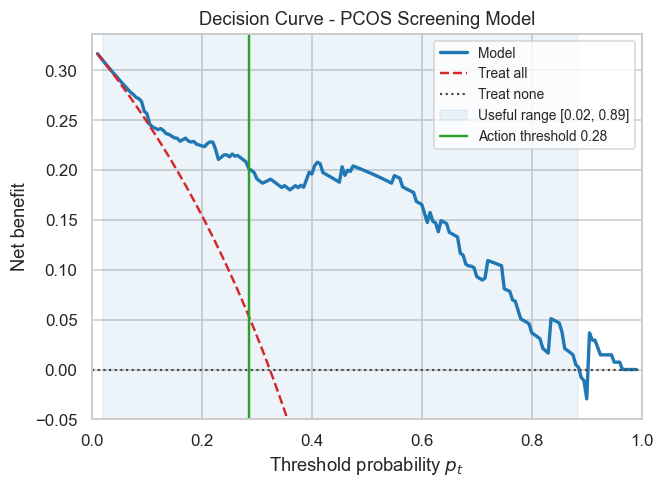

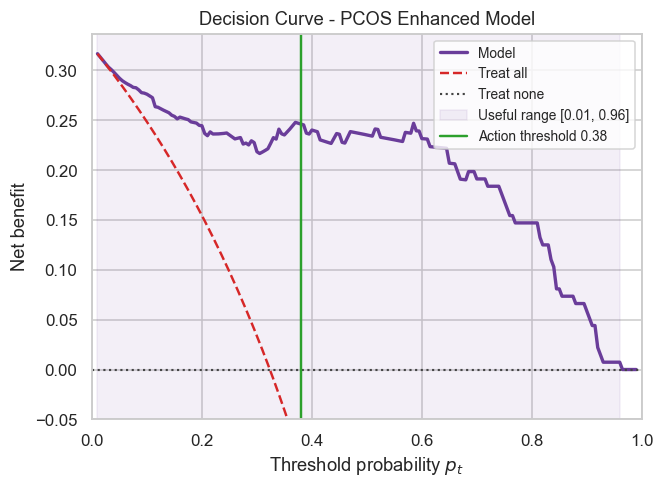

In [6]:
def plot_dca(ax, pt_grid, result, title, colour):
    nb_model = np.asarray(result["net_benefit_model"])
    nb_treat_all = np.asarray(result["net_benefit_treat_all"])
    pt = np.asarray(pt_grid)
    ax.plot(pt, nb_model, color=colour, linewidth=2.2, label="Model")
    ax.plot(pt, nb_treat_all, color="#d62728", linestyle="--", linewidth=1.6, label="Treat all")
    ax.axhline(0.0, color="#444", linestyle=":", linewidth=1.4, label="Treat none")
    lo, hi = result["useful_range"]
    if lo is not None:
        ax.axvspan(lo, hi, color=colour, alpha=0.08,
                   label=f"Useful range [{lo:.2f}, {hi:.2f}]")
    ax.axvline(result["threshold"], color="#2ca02c", linewidth=1.6,
               label=f"Action threshold {result['threshold']:.2f}")
    nb_floor = min(0.0, float(np.min(nb_treat_all)))
    nb_ceiling = float(np.max(nb_model)) + 0.02
    ax.set_ylim(max(nb_floor, -0.05), nb_ceiling)
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("Threshold probability $p_t$")
    ax.set_ylabel("Net benefit")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=9)

for key, cfg in MODEL_CONFIGS.items():
    fig, ax = plt.subplots(figsize=(6.2, 4.6))
    plot_dca(ax, PT_GRID, dca_results[key], cfg["title"], cfg["colour"])
    fig.tight_layout()
    fig.savefig(cfg["figure"], dpi=160, bbox_inches="tight")
    plt.show()


### Combined view: screening vs enhanced

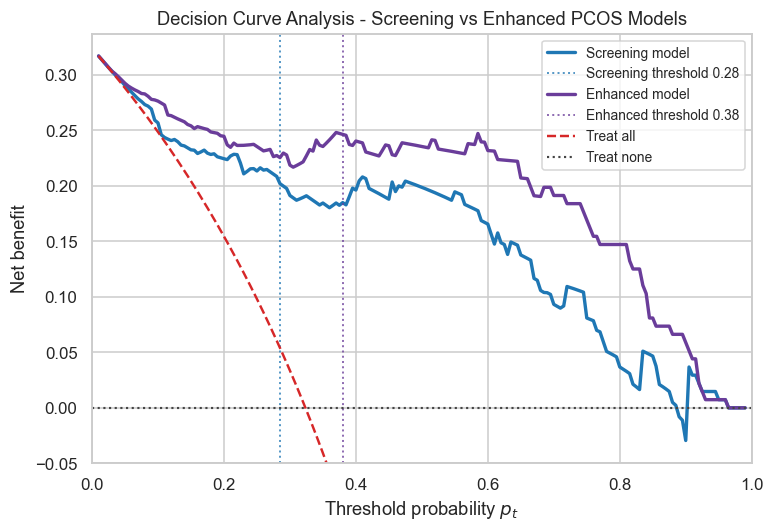

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 5.0))
for key, cfg in MODEL_CONFIGS.items():
    nb_model = np.asarray(dca_results[key]["net_benefit_model"])
    ax.plot(PT_GRID, nb_model, color=cfg["colour"], linewidth=2.2,
            label=f"{key.capitalize()} model")
    ax.axvline(dca_results[key]["threshold"], color=cfg["colour"],
               linestyle=":", linewidth=1.3, alpha=0.75,
               label=f"{key.capitalize()} threshold {dca_results[key]['threshold']:.2f}")

nb_treat_all = np.asarray(dca_results["screening"]["net_benefit_treat_all"])
ax.plot(PT_GRID, nb_treat_all, color="#d62728", linestyle="--", linewidth=1.6, label="Treat all")
ax.axhline(0.0, color="#444", linestyle=":", linewidth=1.4, label="Treat none")

nb_max = max(np.max(dca_results[k]["net_benefit_model"]) for k in dca_results)
ax.set_ylim(-0.05, float(nb_max) + 0.02)
ax.set_xlim(0.0, 1.0)
ax.set_xlabel("Threshold probability $p_t$")
ax.set_ylabel("Net benefit")
ax.set_title("Decision Curve Analysis - Screening vs Enhanced PCOS Models")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "dca_combined.png", dpi=160, bbox_inches="tight")
plt.show()


## Persist Metrics

In [8]:
metrics_path = METRIC_DIR / "dca.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(dca_results, f, indent=2)
print("Saved:", metrics_path)


Saved: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-aa905b50e9a0daad4\outputs\metrics\dca.json


## Interpretation

- The screening model is intended for primary-care triage, where the cost of missing a PCOS case is high relative to the cost of an extra referral. Low threshold probabilities (roughly 0.05-0.30) reflect that preference, and the decision curve shows positive net benefit over **treat all** across this range.
- The enhanced model adds labs and ultrasound, which lifts net benefit at higher thresholds. This is the regime where false positives carry real harm (invasive workup, anxiety), so a higher pt is appropriate.
- The deployed action thresholds from notebooks 02 (0.285) and 03 (0.38) both sit comfortably inside the clinically-useful range identified here.


## Output Verification

In [9]:
expected_outputs = [
    FIGURE_DIR / "dca_screening.png",
    FIGURE_DIR / "dca_enhanced.png",
    FIGURE_DIR / "dca_combined.png",
    METRIC_DIR / "dca.json",
]
for path in expected_outputs:
    assert path.exists(), f"Missing output: {path}"
    assert path.stat().st_size > 0, f"Empty output: {path}"
print("All expected outputs exist and are non-empty.")


All expected outputs exist and are non-empty.
